In [1]:
#Data Cleaning & Preprocessing– Handling missing values, duplicates, inconsistent formats, and feature engineering.

In [2]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv('/content/crypto_2000_records (1).csv')



In [4]:
df.head()

,name,symbol,current_price,market_cap,total_volume
0,Bitcoin,btc,90482.000000,1806857453346,2.851830e+10
1,Ethereum,eth,3089.130000,372658294176,1.298239e+10
2,Tether,usdt,0.998756,186737282793,4.749355e+10
3,XRP,xrp,2.090000,126721710144,2.288538e+09
4,BNB,bnb,903.870000,124497576713,1.220076e+09


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2250 entries, 0 to 2249
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           2250 non-null   object 
 1   symbol         2250 non-null   object 
 2   current_price  2250 non-null   float64
 3   market_cap     2250 non-null   int64  
 4   total_volume   2250 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 88.0+ KB


In [6]:
df.describe()


,current_price,market_cap,total_volume
count,2.250000e+03,2.250000e+03,2.250000e+03
mean,7.722801e+03,1.485144e+09,5.697269e+07
std,2.678741e+05,3.934234e+10,1.214441e+09
min,1.816480e-10,4.453041e+06,0.000000e+00
25%,1.752907e-02,9.377540e+06,4.230425e+04
50%,1.452400e-01,2.142643e+07,5.608010e+05
75%,1.062750e+00,6.736192e+07,4.088488e+06
max,1.269362e+07,1.806857e+12,4.749355e+10


In [7]:
# Handling Duplicates

In [8]:
initial_len = len(df)
df = df.drop_duplicates()
print("Removed {initial_len -len(df)} duplicate records.")

Removed {initial_len -len(df)} duplicate records.


In [9]:
#Handling Missing Values & Inconsistencies

In [10]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
name             0
symbol           0
current_price    0
market_cap       0
total_volume     0
dtype: int64


In [11]:
df['total_volume'] = df['total_volume'].replace(0, df['total_volume'].median())

In [12]:
#Standardizing Formats

In [13]:
df['symbol'] = df['symbol'].str.upper()
df['name'] = df['name'].str.strip()

In [14]:
#Feature Engineering

In [15]:
print(" Performing Feature Engineering ")

 Performing Feature Engineering 


In [16]:
df['vol_mc_ratio'] = df['total_volume'] / df['market_cap']

In [17]:
df['log_current_price'] = np.log1p(df['current_price'])
df['log_market_cap'] = np.log1p(df['market_cap'])

In [18]:
df['market_cap_category'] = pd.qcut(df['market_cap'], q=3, labels=['Low', 'Medium', 'High'])


In [19]:
print("Preprocessing Complete")
print(df.head())

Preprocessing Complete
       name symbol  current_price     market_cap  total_volume  vol_mc_ratio  \
0   Bitcoin    BTC   90482.000000  1806857453346  2.851830e+10      0.015783   
1  Ethereum    ETH    3089.130000   372658294176  1.298239e+10      0.034837   
2    Tether   USDT       0.998756   186737282793  4.749355e+10      0.254334   
3       XRP    XRP       2.090000   126721710144  2.288538e+09      0.018060   
4       BNB    BNB     903.870000   124497576713  1.220076e+09      0.009800   

   log_current_price  log_market_cap market_cap_category  
0          11.412917       28.222610                High  
1           8.035968       26.643928                High  
2           0.692525       25.952969                High  
3           1.128171       25.565259                High  
4           6.807791       25.547552                High  


In [20]:
df.to_csv('cleaned_crypto_data.csv', index=False)

In [21]:
#Exploratory Data Analysis & Visualization

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
df = pd.read_csv('/content/cleaned_crypto_data.csv')

In [24]:
print("Statistical Summary ")
print(df.describe())

Statistical Summary 
       current_price    market_cap  total_volume  vol_mc_ratio  \
count   2.250000e+03  2.250000e+03  2.250000e+03  2.250000e+03   
mean    7.722801e+03  1.485144e+09  5.698191e+07  1.284712e-01   
std     2.678741e+05  3.934234e+10  1.214440e+09  6.134768e-01   
min     1.816480e-10  4.453041e+06  1.832400e-04  1.510812e-11   
25%     1.752907e-02  9.377540e+06  5.354375e+04  2.473038e-03   
50%     1.452400e-01  2.142643e+07  5.610205e+05  2.368565e-02   
75%     1.062750e+00  6.736192e+07  4.088488e+06  9.623924e-02   
max     1.269362e+07  1.806857e+12  4.749355e+10  2.023990e+01   

       log_current_price  log_market_cap  
count       2.250000e+03     2250.000000  
mean        1.229434e+00       17.273702  
std         2.522211e+00        1.650544  
min         1.816480e-10       15.309098  
25%         1.737721e-02       16.053828  
50%         1.356141e-01       16.880136  
75%         7.240400e-01       18.025588  
max         1.635661e+01       28.222610

In [25]:
df.shape


(2250, 9)

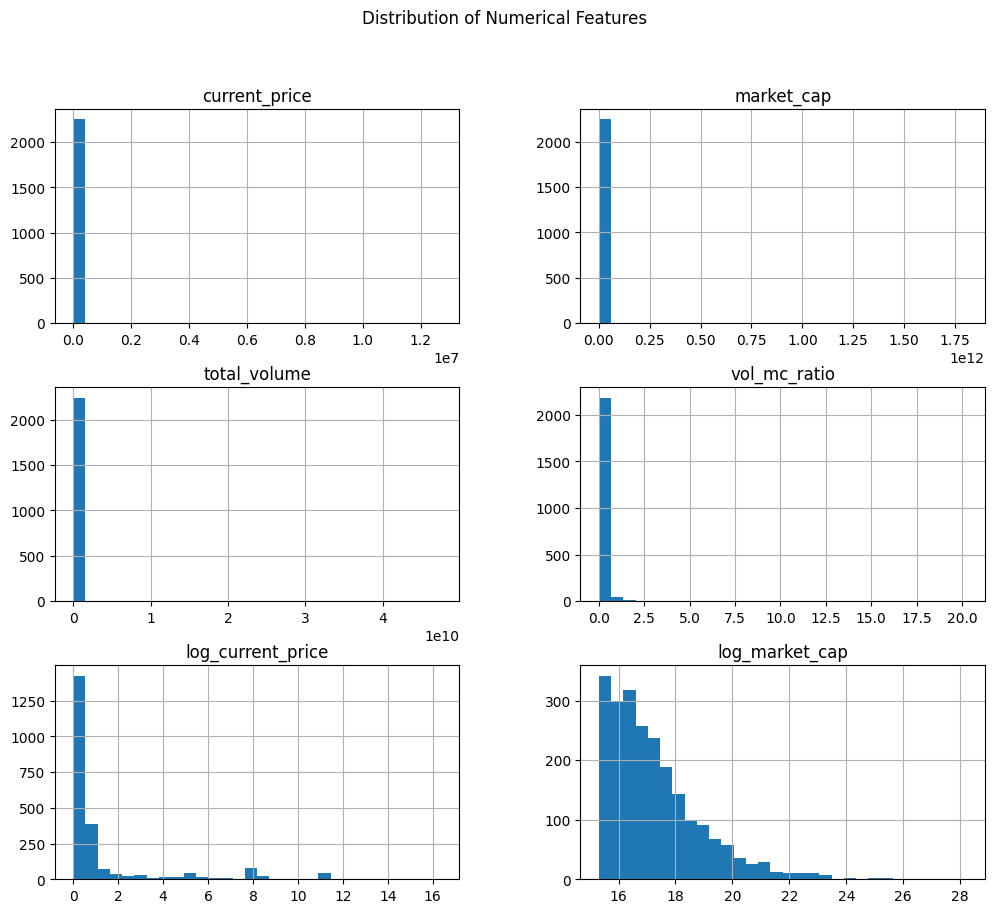

In [26]:
df.hist(figsize=(12,10), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()


/tmp/ipython-input-581619806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='market_cap', y='name', data=top_10_mc, palette='viridis')


Text(0, 0.5, 'Cryptocurrency Name')

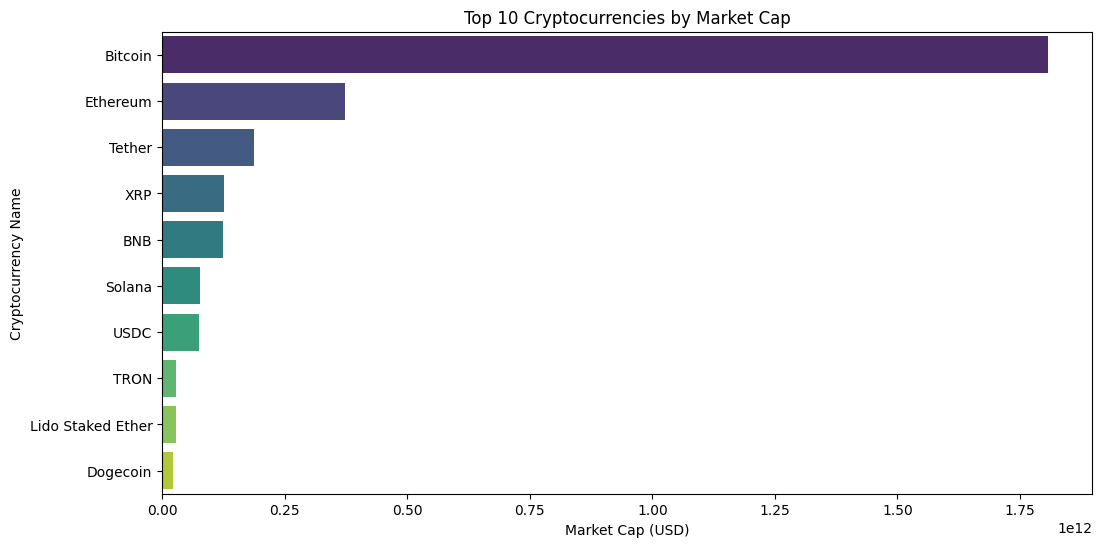

In [27]:
plt.figure(figsize=(12, 6))
top_10_mc = df.nlargest(10, 'market_cap')
sns.barplot(x='market_cap', y='name', data=top_10_mc, palette='viridis')
plt.title('Top 10 Cryptocurrencies by Market Cap')
plt.xlabel('Market Cap (USD)')
plt.ylabel('Cryptocurrency Name')


Text(0.5, 1.0, 'Correlation Heatmap')

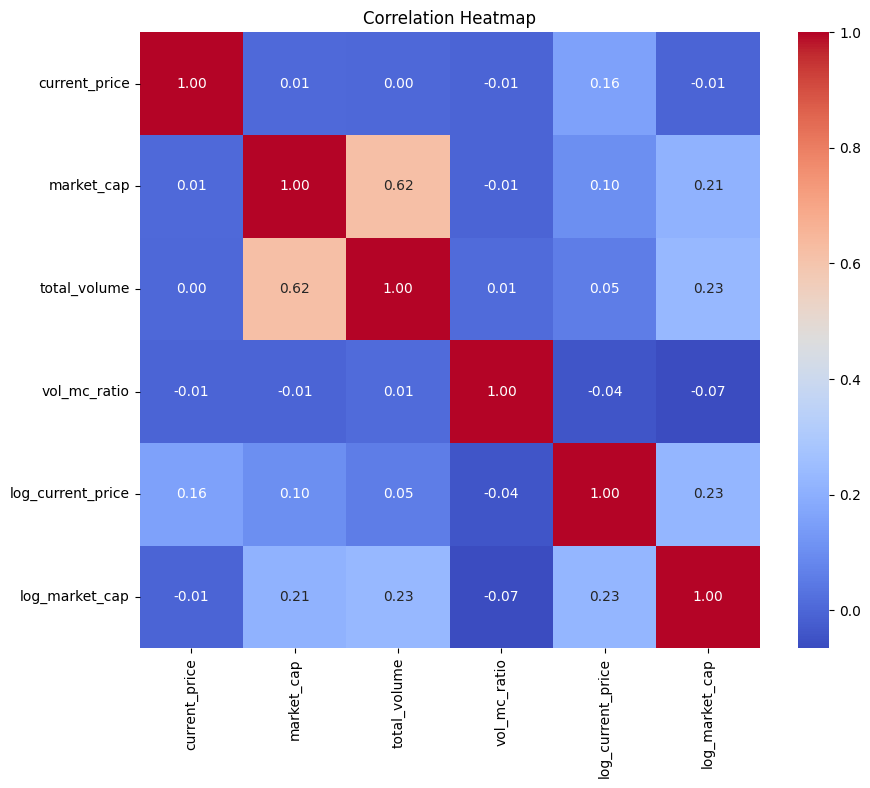

In [28]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

Text(0.5, 1.0, 'Distribution of Log-Transformed Market Cap')

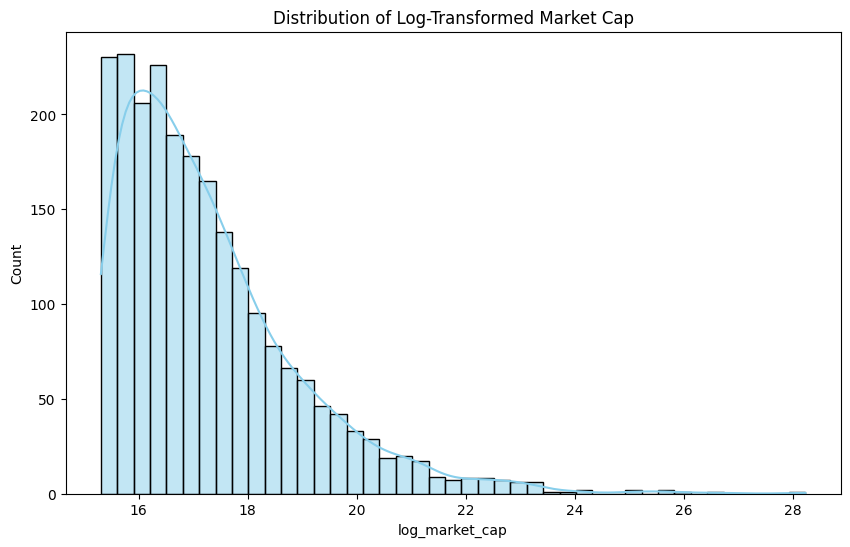

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['log_market_cap'], kde=True, color='skyblue')
plt.title('Distribution of Log-Transformed Market Cap')

Text(0.5, 1.0, 'Log Price vs Log Market Cap')

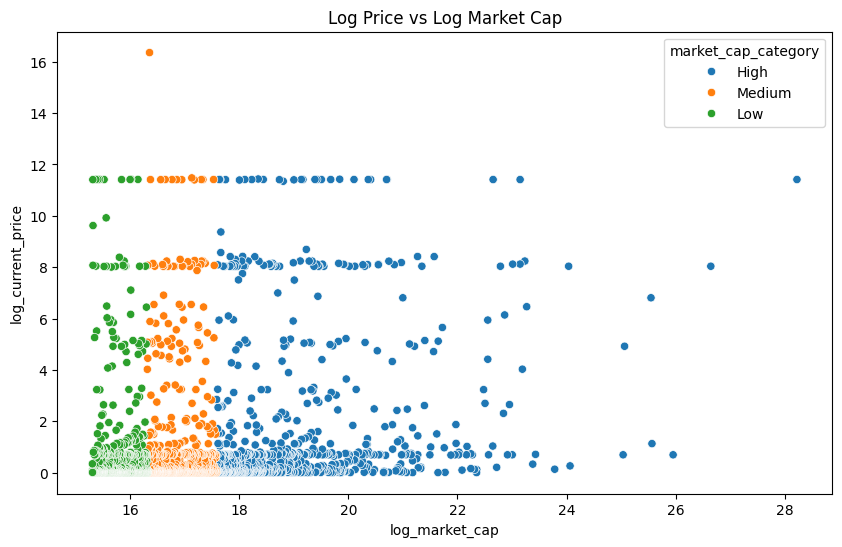

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='log_market_cap', y='log_current_price', data=df, hue='market_cap_category')
plt.title('Log Price vs Log Market Cap')

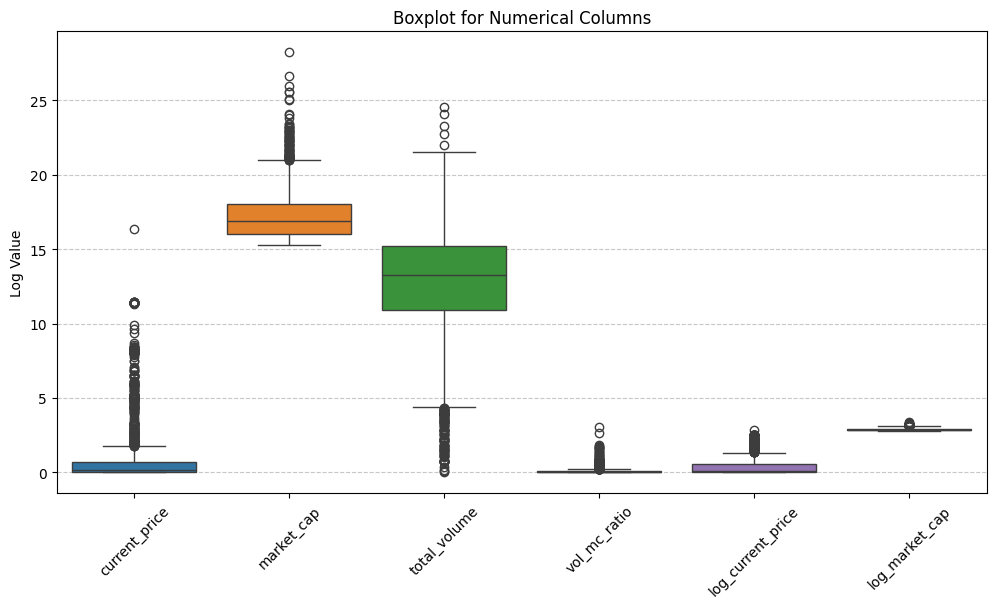

In [31]:
plt.figure(figsize=(12,6))
numerical_data_log = df.select_dtypes(include=['int64', 'float64']).apply(np.log1p)
sns.boxplot(data=numerical_data_log)
plt.xticks(rotation=45)
plt.title("Boxplot for Numerical Columns")
plt.ylabel("Log Value")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [32]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col} - Outliers Count:", outliers.shape[0])


current_price - Outliers Count: 404
market_cap - Outliers Count: 340
total_volume - Outliers Count: 303
vol_mc_ratio - Outliers Count: 241
log_current_price - Outliers Count: 357
log_market_cap - Outliers Count: 82


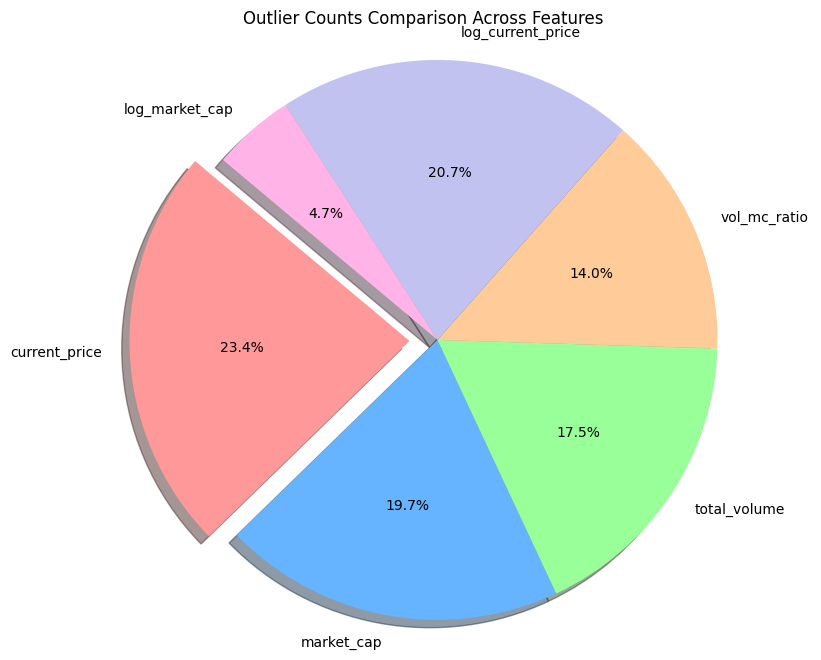

In [33]:
outlier_counts = {}
for col in df.select_dtypes(include=['int64','float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    current_col_outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    outlier_counts[col] = current_col_outliers.shape[0]

labels = list(outlier_counts.keys())
values = list(outlier_counts.values())

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']
explode = [0.1 if value == max(values) else 0 for value in values]

plt.figure(figsize=(10, 8))
plt.pie(values, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',shadow=True, startangle=140)
plt.axis('equal')
plt.title('Outlier Counts Comparison Across Features')
plt.show()

In [34]:
#Model Building & Evaluation

In [35]:
#Clustering Model

In [36]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

cluster_features = ['log_current_price', 'log_market_cap', 'vol_mc_ratio']
X = df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
print(f"Clustering Silhouette Score: {silhouette_score(X_scaled, df['cluster']):.4f}")

Clustering Silhouette Score: 0.5058


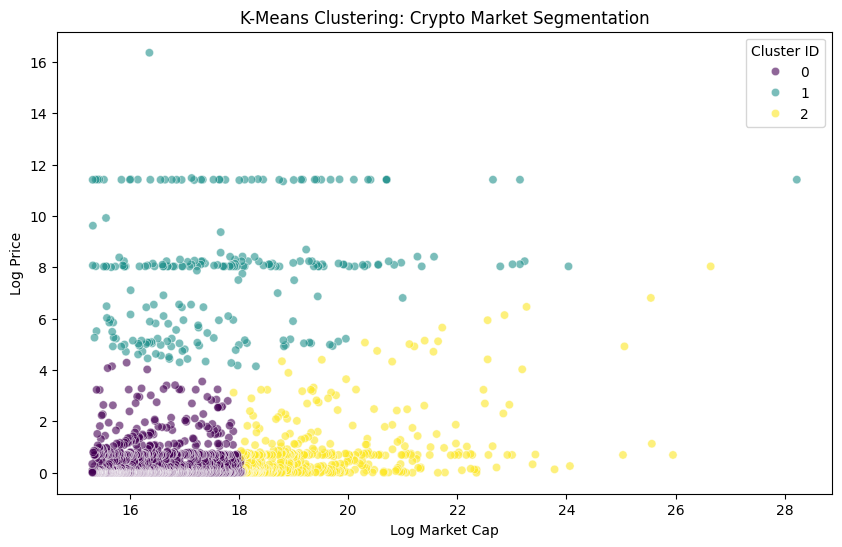

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='log_market_cap', y='log_current_price', hue='cluster', palette='viridis', alpha=0.6)
plt.title('K-Means Clustering: Crypto Market Segmentation')
plt.xlabel('Log Market Cap')
plt.ylabel('Log Price')
plt.legend(title='Cluster ID')
plt.show()

In [38]:
#Regression Model

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_reg = df[['log_current_price', 'total_volume']]
y_reg = df['log_market_cap']
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)
print(f"Regression R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}")

Regression R-squared: 0.3573
Mean Absolute Error: 0.9741


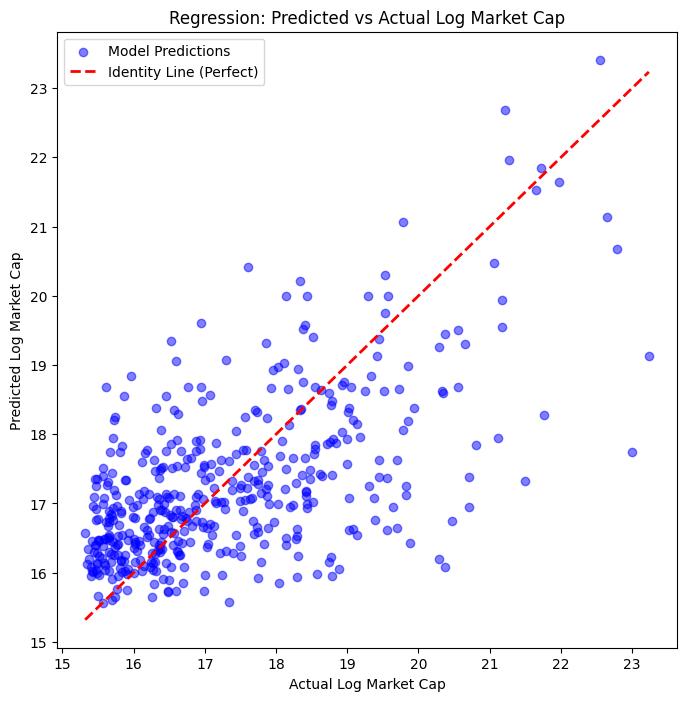

In [40]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Model Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Identity Line (Perfect)')
plt.title('Regression: Predicted vs Actual Log Market Cap')
plt.xlabel('Actual Log Market Cap')
plt.ylabel('Predicted Log Market Cap')
plt.legend()
plt.show()

In [41]:
#Classification Model

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_clf = df[['log_current_price', 'total_volume', 'vol_mc_ratio']]
y_clf = df['market_cap_category']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train_c, y_train_c)
y_pred_c = clf_model.predict(X_test_c)
print("Classification Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}")
print("\nDetailed Report:\n", classification_report(y_test_c, y_pred_c))

Classification Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}

Detailed Report:
               precision    recall  f1-score   support

        High       0.96      0.87      0.91       166
         Low       0.83      0.89      0.86       149
      Medium       0.77      0.79      0.78       135

    accuracy                           0.85       450
   macro avg       0.85      0.85      0.85       450
weighted avg       0.86      0.85      0.85       450



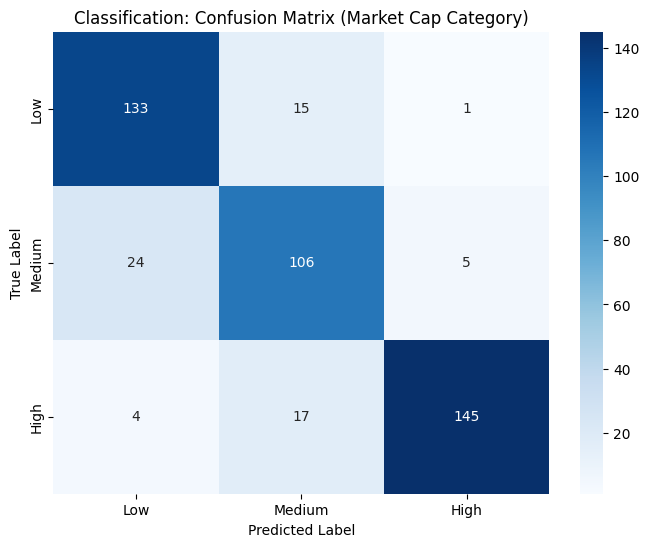

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_c, y_pred_c, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title('Classification: Confusion Matrix (Market Cap Category)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

/tmp/ipython-input-676422192.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='magma')


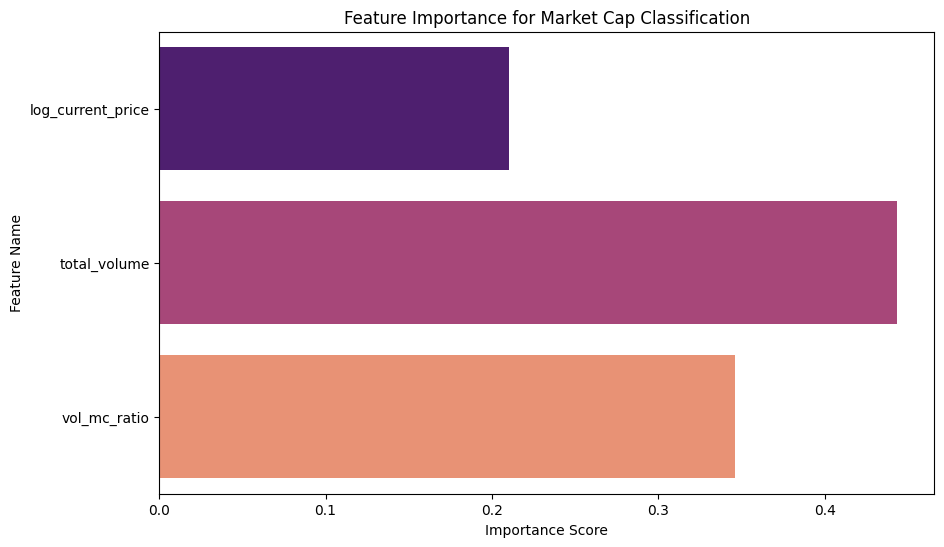

In [44]:
importances = clf_model.feature_importances_
feature_names = ['log_current_price', 'total_volume', 'vol_mc_ratio']

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='magma')
plt.title('Feature Importance for Market Cap Classification')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

In [45]:
!pip install -q streamlit plotly scikit-learn
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 62.9 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 3s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴npm notice
npm notice New major version of npm available! 10.8.2 -> 11.7.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.7.0
npm notice To update run: npm install -g npm@11.7.0
npm notice
⠦

In [46]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- Page Config ---
st.set_page_config(page_title="Colab Crypto Dashboard", layout="wide")

# --- Load Data ---
@st.cache_data
def load_data():
    # Make sure 'cleaned_crypto_data.csv' exists in your Colab files
    return pd.read_csv('cleaned_crypto_data.csv')

df = load_data()

# --- Sidebar Sync Slicers ---
st.sidebar.header("Dashboard Filters")
category = st.sidebar.multiselect("Market Tier", options=df['market_cap_category'].unique(), default=df['market_cap_category'].unique())
filtered_df = df[df['market_cap_category'].isin(category)]

# --- KPIs ---
st.title("🚀 Interactive Crypto Dashboard")
c1, c2, c3 = st.columns(3)
c1.metric("Total Market Cap", f"${filtered_df['market_cap'].sum():,.0f}")
c2.metric("Avg Price", f"${filtered_df['current_price'].mean():,.2f}")
c3.metric("Asset Count", len(filtered_df))

# --- Graphical Representations ---
st.markdown("### 📊 Visual Insights")
row1_col1, row1_col2 = st.columns(2)

with row1_col1:
    # 1. Treemap (Hierarchy Visual)
    fig_tree = px.treemap(filtered_df.nlargest(30, 'market_cap'),
                          path=['market_cap_category', 'name'],
                          values='market_cap', title="Market Hierarchy (Top 30)")
    st.plotly_chart(fig_tree, use_container_width=True)

with row1_col2:
    # 2. Scatter Plot (AI Relationship)
    fig_scatter = px.scatter(filtered_df, x="market_cap", y="total_volume",
                             color="market_cap_category", log_x=True, log_y=True,
                             title="Volume vs Market Cap (Log Scale)")
    st.plotly_chart(fig_scatter, use_container_width=True)

# --- AI Feature: Clustering ---
st.markdown("### 🤖 AI Segmentation (K-Means)")
X = filtered_df[['log_current_price', 'log_market_cap']]
kmeans = KMeans(n_clusters=3, random_state=42).fit(StandardScaler().fit_transform(X))
filtered_df['Cluster'] = kmeans.labels_.astype(str)

fig_cluster = px.scatter(filtered_df, x="log_market_cap", y="log_current_price",
                         color="Cluster", title="AI Cluster Analysis")
st.plotly_chart(fig_cluster, use_container_width=True)

# --- Drill Through ---
with st.expander("🔍 Detailed Data Table"):
    st.dataframe(filtered_df)

Writing app.py


In [47]:
import urllib
print("Password/Enpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

# Start streamlit in the background
!streamlit run app.py & npx localtunnel --port 8501

Password/Enpoint IP for localtunnel is: 34.16.186.203
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧

⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://easy-cases-own.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.186.203:8501

  Stopping...
^C
